# Surrogate / oracle on the 85%-identity split — random vs 70% vs 85%

Trains the **same** two fixed models as `surrogate_oracle_peak_dual.ipynb`
(surrogate=`cnn-max-d1`, oracle=`cnn-concatstd-d1`) with identical architectures, loss,
hyperparameters, and ESM-2 embedding cache, on `dual_splits_seqid85.csv`. Then compares
held-out peak-MAE across the **random**, **70%-identity**, and **85%-identity** splits.

Nothing existing is modified: `peak_models.py` is imported read-only, the shared ESM cache is
reused, and new checkpoints are written under a `seqid85_` prefix.

> Prerequisites: run `seqid85_cluster_split.ipynb` (writes the split). The 70% comparison row
> also needs `seqid70_surrogate_net.pt` / `seqid70_oracle_net.pt` from the 70% run; it is skipped
> gracefully if those are absent.


## 0. Setup + data + embeddings  *(identical to the dual notebook)*

In [ ]:
import os, sys
# Moved into peak_design/cluster_split/. These notebooks are written to run from
# peak_design/, so re-anchor cwd + import path there; every relative path
# (../dataset_pipeline, trained_models/, oracle_cv_cache/) then resolves unchanged.
if os.path.basename(os.getcwd()) == "cluster_split":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

In [1]:
import csv, os, numpy as np, torch, torch.nn as nn, hashlib, time
import peak_models as pm
try:
    import arcadia_pycolor as apc; apc.mpl.setup(); HAVE_APC=True
except Exception:
    HAVE_APC=False
try:
    import matplotlib.pyplot as plt; HAVE_PLT=True
except Exception:
    HAVE_PLT=False
class _C:
    def __getattr__(self,k): return getattr(apc,k) if HAVE_APC else {"aegean":"#2b6c8f","amber":"#f6a200","rose":"#c5474b","seaweed":"#3b8a6e","gray":"#888888","wish":"#5088c5","aster":"#7a5ea8","dragon":"#c85152"}.get(k,"#333333")
apc_c=_C()
CUR="../dataset_pipeline/data/peak/curated"
dev=torch.device("mps") if (getattr(torch.backends,"mps",None) and torch.backends.mps.is_available()) \
    else (torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu"))
rows=list(csv.DictReader(open(os.path.join(CUR,"peaks_assignments.csv")))); N=len(rows)
peaks=np.load(os.path.join(CUR,"peaks.npy")).astype(np.float32); EXM=peaks[:,0]; EMM=peaks[:,1]
seqs=[None]*N; h=None
for line in open(os.path.join(CUR,"sequences.fasta")):
    line=line.strip()
    if line.startswith(">"): h=int(line[1:].split("|")[0])
    elif line: seqs[h]=line
RP=os.path.join(CUR,"esm_residue_fp16.npy"); LP=os.path.join(CUR,"esm_residue_len.npy")
H=np.load(RP); Ls=np.load(LP); Lmax=int(Ls.max()); H=H[:,:Lmax]
Ht=torch.tensor(H); ar=torch.arange(Lmax); os.makedirs("trained_models",exist_ok=True)
def batches(idx,bs=32,shuffle=False):
    idx=np.array(idx)
    if shuffle: np.random.shuffle(idx)
    for i in range(0,len(idx),bs):
        b=idx[i:i+bs]
        yield Ht[b].float().to(dev),(ar.unsqueeze(0)<torch.tensor(Ls[b]).unsqueeze(1)).to(dev),b
print("device",dev,"| N",N)


device mps | N 758


## 1. Load the 85%-identity dual split

In [2]:
SPLIT=os.path.join(CUR,"dual_splits_seqid85.csv")
assert os.path.exists(SPLIT), "run seqid85_cluster_split.ipynb first"
ds=sorted(csv.DictReader(open(SPLIT)), key=lambda r:int(r["index"])); assert len(ds)==N
Srole=np.array([r["surrogate_role"] for r in ds]); Orole=np.array([r["oracle_role"] for r in ds])
assert np.all(Orole[Srole=="test"]=="train") and np.all(Srole[Orole=="test"]=="train")
assert np.sum((Srole=="val")&(Orole=="val"))==0
def cnt(a): return {b:int((a==b).sum()) for b in ("train","val","test")}
print("seqid85 split | surrogate (S):",cnt(Srole),"| oracle (O):",cnt(Orole))
SIDX={b:np.where(Srole==b)[0] for b in ("train","val","test")}
OIDX={b:np.where(Orole==b)[0] for b in ("train","val","test")}


seqid85 split | surrogate (S): {'train': 510, 'val': 119, 'test': 129} | oracle (O): {'train': 530, 'val': 114, 'test': 114}


## 2. Models + training helpers  *(same code path as the dual notebook)*

In [3]:
DROP=0.2; LR=1e-3; WD=1e-4; EP_CNN=150; FORCE=False; SEED=0
MODELS=[dict(arch="cnn", pool="max",       conv_ch=128, k=5, n_conv=1, hidden=256, nl=2, sid="cnn-max-d1"),
        dict(arch="cnn", pool="concatstd", conv_ch=128, k=5, n_conv=1, hidden=256, nl=2, sid="cnn-concatstd-d1")]
SPEC={m["sid"]:m for m in MODELS}
SURR_SID, ORAC_SID = "cnn-max-d1", "cnn-concatstd-d1"
def standardizer(idx):
    m=peaks[idx].mean(0); s=peaks[idx].std(0)+1e-6; return m.astype(np.float32), s.astype(np.float32)
def wrapw(base, mean, std): return pm.wrap(base, mean, std, dev)
def load_wrapped(path, mean, std): base,ck=pm.load_model(path,dev); return wrapw(base,mean,std), ck
Pk=torch.tensor(peaks, dtype=torch.float32, device=dev)
def predict_peaks(net, idx):
    net.eval(); ps=[]
    with torch.no_grad():
        for Hb,mk,b in batches(idx): ps.append(net(Hb,mk).cpu().numpy())
    return np.concatenate(ps)
def _r2(t,p):
    t=np.asarray(t,float); p=np.asarray(p,float); ss=((t-t.mean())**2).sum()
    return 1-((t-p)**2).sum()/ss if ss>0 else float("nan")
def evaluate(net, idx):
    P=predict_peaks(net, idx); T=peaks[idx]
    ex=float(np.abs(P[:,0]-T[:,0]).mean()); em=float(np.abs(P[:,1]-T[:,1]).mean())
    return dict(mae=0.5*(ex+em), ex_mae=ex, em_mae=em, r2_ex=_r2(T[:,0],P[:,0]), r2_em=_r2(T[:,1],P[:,1]))
def fit(net, mean, std, tr, va, epochs):
    sd=torch.tensor(std,device=dev); opt=torch.optim.Adam(net.parameters(),LR,weight_decay=WD); best=1e9; bst=None
    for ep in range(epochs):
        net.train()
        for Hb,mk,b in batches(tr,shuffle=True):
            opt.zero_grad(); pred=net(Hb,mk); tgt=Pk[torch.as_tensor(b,device=dev)]
            loss=(((pred-tgt)/sd)**2).mean(); loss.backward(); opt.step()
        v=evaluate(net,va)["mae"]
        if v<best: best=v; bst={k:vv.cpu().clone() for k,vv in net.base.state_dict().items()}
    net.base.load_state_dict(bst); return net
DATASIG=hashlib.md5(Srole.tobytes()+Orole.tobytes()).hexdigest()[:8]
print("seqid85 DATASIG",DATASIG)
def get_or_train(spec, dsname, tr, va, te, mean, std):
    path=os.path.join("trained_models", f"seqid85_{dsname}_{spec['sid']}_peaks_{DATASIG}.pt")
    if os.path.exists(path) and not FORCE:
        net,_=load_wrapped(path, mean, std)
        return {"train":evaluate(net,tr),"val":evaluate(net,va),"test":evaluate(net,te)}, True, path
    torch.manual_seed(SEED); np.random.seed(SEED)
    base=pm.build_base(spec, dev, drop=DROP); net=wrapw(base, mean, std)
    fit(net, mean, std, tr, va, EP_CNN)
    met={"train":evaluate(net,tr),"val":evaluate(net,va),"test":evaluate(net,te)}
    meta=dict(spec); meta.update(out=pm.N_PEAKS, drop=DROP, sid=spec["sid"], metrics=met, loss="std-mse",
                                 split="seqid85", peak_mean=mean.tolist(), peak_std=std.tolist())
    pm.save_model(path, net.base, meta); return met, False, path


seqid85 DATASIG 0cb01d83


## 3. Train surrogate (`cnn-max-d1` on S) and oracle (`cnn-concatstd-d1` on O)

In [4]:
def run(dsname, IDX, sid):
    mean,std=standardizer(IDX["train"])
    met,cached,path=get_or_train(SPEC[sid], dsname, IDX["train"], IDX["val"], IDX["test"], mean, std)
    print(f"{dsname:5s} {sid:16s} {'(cached)' if cached else '(trained)'} | "
          f"train MAE {met['train']['mae']:4.1f} | val MAE {met['val']['mae']:4.1f} | test MAE {met['test']['mae']:4.1f} "
          f"(test R2 ex {met['test']['r2_ex']:.2f} em {met['test']['r2_em']:.2f})")
    return met,path,(mean,std)
t0=time.time()
surr_met, surr_path, surr_scaler = run("surr", SIDX, SURR_SID)
orac_met, orac_path, orac_scaler = run("orac", OIDX, ORAC_SID)
print(f"done in {time.time()-t0:.0f}s")


surr  cnn-max-d1       (trained) | train MAE  3.8 | val MAE 28.5 | test MAE 39.8 (test R2 ex -0.04 em -0.14)


orac  cnn-concatstd-d1 (trained) | train MAE  2.9 | val MAE 23.6 | test MAE 26.9 (test R2 ex 0.09 em -0.01)
done in 214s


## 4. Save chosen seqid85 models  *(new files — existing weights untouched)*

In [5]:
import shutil
shutil.copy(surr_path, os.path.join("trained_models","seqid85_surrogate_net.pt"))
shutil.copy(orac_path, os.path.join("trained_models","seqid85_oracle_net.pt"))
np.savez(os.path.join("trained_models","seqid85_surrogate_scaler.npz"), mean=surr_scaler[0], std=surr_scaler[1])
np.savez(os.path.join("trained_models","seqid85_oracle_scaler.npz"),    mean=orac_scaler[0], std=orac_scaler[1])
print("saved -> trained_models/seqid85_surrogate_net.pt, seqid85_oracle_net.pt (+ scalers)")


saved -> trained_models/seqid85_surrogate_net.pt, seqid85_oracle_net.pt (+ scalers)


## 5. Oracle parity by split region

oracle = cnn-concatstd-d1
region                        n    MAE  ex_MAE  em_MAE  R2_ex  R2_em


O_train                     530    2.9     3.3     2.5   0.99   1.00
O_val                       114   23.6    24.8    22.5   0.49   0.54
O_test (unseen lineages)    114   26.9    29.2    24.5   0.09  -0.01


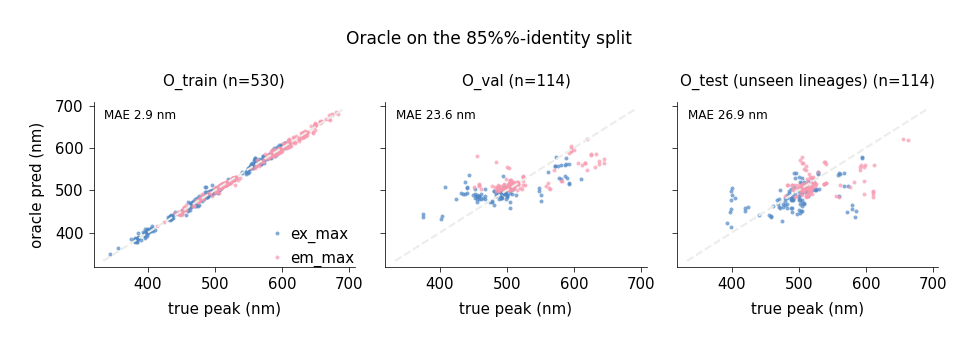

In [6]:
orac_net,_=load_wrapped(orac_path,*orac_scaler)
groups=[("O_train",OIDX["train"]),("O_val",OIDX["val"]),("O_test (unseen lineages)",OIDX["test"])]
print(f"oracle = {ORAC_SID}")
print(f"{'region':26s} {'n':>4} {'MAE':>6} {'ex_MAE':>7} {'em_MAE':>7} {'R2_ex':>6} {'R2_em':>6}")
for name,idx in groups:
    m=evaluate(orac_net,idx)
    print(f"{name:26s} {len(idx):>4} {m['mae']:6.1f} {m['ex_mae']:7.1f} {m['em_mae']:7.1f} {m['r2_ex']:6.2f} {m['r2_em']:6.2f}")
if HAVE_PLT:
    lo=float(min(EXM.min(),EMM.min()))-10; hi=float(max(EXM.max(),EMM.max()))+10
    fig,axes=plt.subplots(1,3,figsize=(13.2,4.3),sharex=True,sharey=True)
    for col,(name,idx) in enumerate(groups):
        P=predict_peaks(orac_net,idx); a=axes[col]; a.plot([lo,hi],[lo,hi],ls="--",color=apc_c.gray)
        a.scatter(peaks[idx,0],P[:,0],s=16,color=apc_c.aegean,alpha=0.7,label="ex_max")
        a.scatter(peaks[idx,1],P[:,1],s=16,color=apc_c.rose,alpha=0.7,label="em_max")
        m=evaluate(orac_net,idx)
        a.text(0.04,0.96,f"MAE {m['mae']:.1f} nm",transform=a.transAxes,va="top",fontsize=12,
               bbox=dict(boxstyle="round,pad=0.2",fc="white",ec="none"))
        a.set_title(f"{name} (n={len(idx)})"); a.set_xlabel("true peak (nm)")
    axes[0].set_ylabel("oracle pred (nm)"); axes[0].legend()
    plt.suptitle(f"Oracle on the 85%%-identity split"); plt.tight_layout(); plt.show()


## 6. Head-to-head: random vs 70% vs 85% split

Each model is evaluated on its **own** held-out test set (evaluating a model on another split's test
would be leaky, since it trained on those lineages). Same architectures, loss, and embeddings — only
the split differs.

**Caveat before reading the numbers.** With one lineage covering ~34% of the data and only tens of
clusters, each homology-aware test set is small (n≈114-129) and dominated by *which* few families
happen to land in it. Changing the threshold reshuffles those families, so the honest MAE is
**high-variance and not a smooth function of the threshold** — do not expect a clean
random < 85% < 70% ordering. The robust, threshold-independent conclusion is the one that matters:
*both* homology-aware splits give much worse test MAE than the random split, i.e. the random number
is optimistic regardless of where the identity cut is drawn.

In [7]:
surr_net,_=load_wrapped(surr_path,*surr_scaler)
def load_roles(path):
    r=sorted(csv.DictReader(open(path)),key=lambda x:int(x["index"]))
    S=np.array([x["surrogate_role"] for x in r]); O=np.array([x["oracle_role"] for x in r])
    return {b:np.where(S==b)[0] for b in ("train","val","test")}, {b:np.where(O==b)[0] for b in ("train","val","test")}
def load_saved(net_pt, scaler_npz):
    sc=np.load(os.path.join("trained_models",scaler_npz)); base,_=pm.load_model(os.path.join("trained_models",net_pt),dev)
    return pm.wrap(base,sc["mean"],sc["std"],dev)
def rowmet(net,idx):
    m=evaluate(net,idx); return (len(idx),m["mae"],m["ex_mae"],m["em_mae"],m["r2_ex"],m["r2_em"])

comp=[]  # (model, split_label, n, mae, ex, em, r2ex, r2em)
RSIDX,ROIDX=load_roles(os.path.join(CUR,"dual_splits.csv"))
r_surr=load_saved("dual_surrogate_net.pt","dual_surrogate_scaler.npz")
r_orac=load_saved("dual_oracle_net.pt","dual_oracle_scaler.npz")
comp.append(("surrogate","random  (leaky)")+rowmet(r_surr,RSIDX["test"]))
comp.append(("oracle",   "random  (leaky)")+rowmet(r_orac,ROIDX["test"]))
# 70% (optional)
if os.path.exists("trained_models/seqid70_surrogate_net.pt"):
    S70,O70=load_roles(os.path.join(CUR,"dual_splits_seqid70.csv"))
    s70=load_saved("seqid70_surrogate_net.pt","seqid70_surrogate_scaler.npz")
    o70=load_saved("seqid70_oracle_net.pt","seqid70_oracle_scaler.npz")
    comp.append(("surrogate","seqid70 (honest)")+rowmet(s70,S70["test"]))
    comp.append(("oracle",   "seqid70 (honest)")+rowmet(o70,O70["test"]))
comp.append(("surrogate","seqid85 (honest)")+rowmet(surr_net,SIDX["test"]))
comp.append(("oracle",   "seqid85 (honest)")+rowmet(orac_net,OIDX["test"]))

print(f"{'model':10s} {'split (own test)':18s} {'n':>4} {'MAE':>6} {'ex':>6} {'em':>6} {'R2_ex':>6} {'R2_em':>6}")
for r in sorted(comp, key=lambda x:(x[0],x[1])):
    print(f"{r[0]:10s} {r[1]:18s} {r[2]:>4} {r[3]:6.1f} {r[4]:6.1f} {r[5]:6.1f} {r[6]:6.2f} {r[7]:6.2f}")


model      split (own test)      n    MAE     ex     em  R2_ex  R2_em
oracle     random  (leaky)     114   13.4   17.0    9.8   0.69   0.84
oracle     seqid70 (honest)    114   36.0   34.9   37.1   0.36   0.37
oracle     seqid85 (honest)    114   26.9   29.2   24.5   0.09  -0.01
surrogate  random  (leaky)     114   11.2   13.4    9.0   0.77   0.87
surrogate  seqid70 (honest)    129   18.1   19.2   17.0  -0.06  -0.25
surrogate  seqid85 (honest)    129   39.8   39.9   39.7  -0.04  -0.14


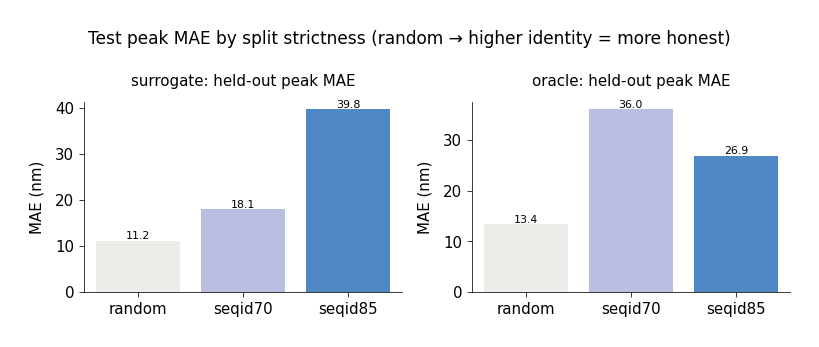

In [8]:
if HAVE_PLT:
    fig,ax=plt.subplots(1,2,figsize=(11,4.3))
    for col,mdl in enumerate(["surrogate","oracle"]):
        sub=[r for r in comp if r[0]==mdl]
        labs=[r[1].split()[0] for r in sub]; mae=[r[3] for r in sub]
        cols=[apc_c.gray if "random" in r[1] else (apc_c.wish if "seqid70" in r[1] else apc_c.aegean) for r in sub]
        b=ax[col].bar(labs,mae,color=cols)
        for rr,v in zip(b,mae): ax[col].text(rr.get_x()+rr.get_width()/2,v+0.3,f"{v:.1f}",ha="center",fontsize=11)
        ax[col].set_title(f"{mdl}: held-out peak MAE"); ax[col].set_ylabel("MAE (nm)")
    plt.suptitle("Test peak MAE by split strictness (random → higher identity = more honest)")
    plt.tight_layout(); plt.show()


## 7. Interpretation

- Architectures, loss, hyperparameters, and ESM-2 embeddings are unchanged; only the split differs.
  New checkpoints saved under `seqid85_*`; the original `dual_*` weights are untouched.
- **What is robust across thresholds:** both the 70% and 85% homology-aware splits push held-out
  peak MAE far above the random-split number (surrogate 11.2 → 18-40 nm; oracle 13.4 → 27-36 nm) and
  collapse R² toward ~0. The random split's low MAE is inflated by ~90-95% train/test homolog leakage
  at either threshold.
- **What is *not* robust:** the exact honest MAE is non-monotonic in the threshold (here surrogate is
  worse at 85% than 70%, oracle is the reverse). That is expected — each cluster-based test set is
  small and its difficulty depends on which lineages are held out, not just on the leakage removed.
  A single split therefore gives a noisy point estimate.
- **Recommendation:** for a stable honest estimate, use **grouped (cluster-based) cross-validation**
  at a fixed threshold — hold out each cluster group in turn and report mean ± std — rather than
  reading one number off one split. Treat 70% as the conservative "novel-family" yardstick and 85%
  as "tolerant of near-duplicates only"; the CV spread, not the point value, is what to compare.
